In [167]:
import os
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import jax
import jax.numpy as jnp
from jax import random
import optax
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Devices :", jax.devices())
print("Backend :", jax.default_backend())


Devices : [CudaDevice(id=0), CudaDevice(id=1)]
Backend : gpu


In [216]:
T             = 100
P             = 0.3
N_THRESHOLD   = int(round(P * T * 0.5))
N_THRESHOLD_2 = int(round(P * T * 0.6))
DELAY         = 5
HIDDEN_SIZE   = 64
BATCH_SIZE    = 512
N_STEPS       = 600_000
LR            = 2e-3
L2_H          = 1e-4
UNIT_NOISE_STD = 0.01
L2_W          = 0
RECORD_EVERY  = 100
SEED          = 3

switch = N_STEPS // 2
print(f"n1={N_THRESHOLD}, n2={N_THRESHOLD_2}, switch at step {switch}")


n1=15, n2=18, switch at step 300000


In [217]:
@jax.custom_vjp
def heaviside_ste(x):
    """Heaviside step in forward pass; sigmoid surrogate gradient in backward."""
    return jnp.heaviside(x, 0.5)

def _ste_fwd(x):
    return heaviside_ste(x), x

def _ste_bwd(x, g):
    sig = jax.nn.sigmoid(x)
    return (g * sig * (1.0 - sig),)

heaviside_ste.defvjp(_ste_fwd, _ste_bwd)


def init_params(key, hidden_size=HIDDEN_SIZE, scale=0.1):
    k1, k2, k3, k4, k5 = random.split(key, 5)
    return dict(
        W_rec     = random.normal(k1, (hidden_size, hidden_size)) * scale / hidden_size**0.5,
        W_in      = random.normal(k2, (hidden_size, 2)) * scale,   # col0=evidence, col1=reset
        b         = random.normal(k3, (hidden_size,)) * scale,
        W_out     = random.normal(k4, (hidden_size,)) * scale,
        threshold = random.normal(k5, ()) * scale,
    )


def forward_single(params, inputs):
    """inputs: (T, 2)  ch0=r_t (evidence), ch1=g_t (reset cue)"""
    def step(h, x):
        h_new = jnp.tanh(params['W_rec'] @ h + params['W_in'] @ x + params['b'])
        z     = params['W_out'] @ h_new
        y     = heaviside_ste(z - params['threshold'])
        return h_new, (y, h_new)
    h0 = jnp.zeros(params['b'].shape)
    _, (ys, hs) = jax.lax.scan(step, h0, inputs)
    return ys, hs   # (T,), (T, H)


forward_batch = jax.vmap(forward_single, in_axes=(None, 0))


def targets(inputs_batch, n_threshold):
    return (jnp.cumsum(inputs_batch[:, :, 0], axis=1) >= n_threshold).astype(jnp.float32)


def sample_batch(key, batch_size, T, p):
    key_r, key_d = random.split(key)
    delays = random.randint(key_d, (batch_size,), 0, DELAY + 1)
    mask   = (jnp.arange(T)[None, :] >= delays[:, None]).astype(jnp.float32)
    g      = 1.0 - mask                        # gate ON exactly during delay, OFF after
    r      = random.bernoulli(key_r, p, (batch_size, T)).astype(jnp.float32)
    return jnp.stack([r * mask, g], axis=-1)   # (B, T, 2)


def forward_single_noisy(params, inputs, noise):
    """Like forward_single but adds Gaussian noise (T, H) to each hidden unit."""
    def step(h, x_n):
        x, n = x_n
        h_new = jnp.tanh(params['W_rec'] @ h + params['W_in'] @ x + params['b']) + n
        z     = params['W_out'] @ h_new
        y     = heaviside_ste(z - params['threshold'])
        return h_new, (y, h_new)
    h0 = jnp.zeros(params['b'].shape)
    _, (ys, hs) = jax.lax.scan(step, h0, (inputs, noise))
    return ys, hs

forward_batch_noisy = jax.vmap(forward_single_noisy, in_axes=(None, 0, 0))


In [218]:
key = random.PRNGKey(SEED)
key, init_key = random.split(key)
params    = init_params(init_key, scale=0.1)
optimizer = optax.adam(LR)
opt_state = optimizer.init(params)

history          = dict(loss=[], acc=[], steps=[])
params_at_switch = None

@jax.jit
def train_step(params, opt_state, key, n_threshold):
    key, data_key, noise_key = random.split(key, 3)
    inputs = sample_batch(data_key, BATCH_SIZE, T, P)
    def loss_with_acc(p):
        noise   = random.normal(noise_key, (BATCH_SIZE, T, HIDDEN_SIZE)) * UNIT_NOISE_STD
        ys, hs  = forward_batch_noisy(p, inputs, noise)
        ys_star = targets(inputs, n_threshold)
        mse     = jnp.mean((ys - ys_star) ** 2)
        l2      = L2_W * sum(jnp.mean(v ** 2) for v in jax.tree_util.tree_leaves(p))
        l2_act  = L2_H * jnp.mean(hs ** 2)
        acc     = jnp.mean((ys > 0.5) == (ys_star > 0.5))
        return mse + l2 + l2_act, acc
    (loss, acc), grads = jax.value_and_grad(loss_with_acc, has_aux=True)(params)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    return optax.apply_updates(params, updates), new_opt_state, loss, acc

for step in range(N_STEPS):
    key, subkey = random.split(key)
    nt = N_THRESHOLD if step < switch else N_THRESHOLD_2
    params, opt_state, loss, acc = train_step(params, opt_state, subkey, nt)
    if step == switch - 1:
        params_at_switch = jax.tree_util.tree_map(lambda x: np.array(x), params)
    if step % RECORD_EVERY == 0:
        history['loss'].append(float(loss))
        history['acc'].append(float(acc))
        history['steps'].append(step)
    if step % 5000 == 0:
        print(f'step {step:6d}  loss={float(loss):.4f}  acc={float(acc):.3f}')


step      0  loss=0.4902  acc=0.510
step   5000  loss=0.1937  acc=0.806
step  10000  loss=0.3287  acc=0.671
step  15000  loss=0.1094  acc=0.891
step  20000  loss=0.1194  acc=0.881
step  25000  loss=0.0879  acc=0.912
step  30000  loss=0.1218  acc=0.878
step  35000  loss=0.0920  acc=0.908
step  40000  loss=0.1059  acc=0.894
step  45000  loss=0.1129  acc=0.887
step  50000  loss=0.1145  acc=0.885
step  55000  loss=0.0849  acc=0.915
step  60000  loss=0.0968  acc=0.903
step  65000  loss=0.0839  acc=0.916
step  70000  loss=0.0951  acc=0.905
step  75000  loss=0.1343  acc=0.866
step  80000  loss=0.0730  acc=0.927
step  85000  loss=0.2099  acc=0.790
step  90000  loss=0.0644  acc=0.936
step  95000  loss=0.1074  acc=0.893
step 100000  loss=0.0674  acc=0.933
step 105000  loss=0.0795  acc=0.921
step 110000  loss=0.0750  acc=0.925
step 115000  loss=0.0607  acc=0.939
step 120000  loss=0.0628  acc=0.937
step 125000  loss=0.0797  acc=0.920
step 130000  loss=0.0682  acc=0.932
step 135000  loss=0.0513  ac

In [230]:
print(f"Final loss={float(loss):.4f}  acc={float(acc):.3f}")

Final loss=0.0945  acc=0.906


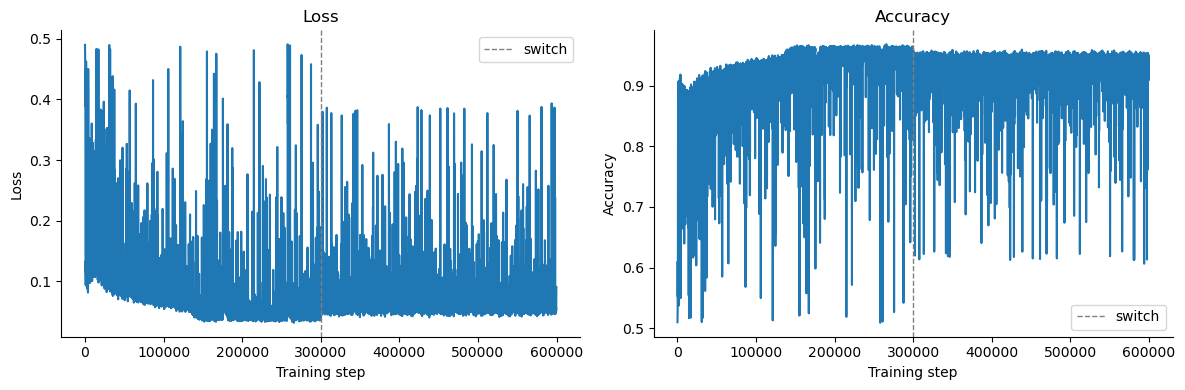

In [219]:
xs = np.array(history['steps'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, key_h, ylabel in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.plot(xs, history[key_h])
    ax.axvline(switch, c='gray', ls='--', lw=1, label='switch')
    ax.set_xlabel('Training step'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel); ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); plt.show()


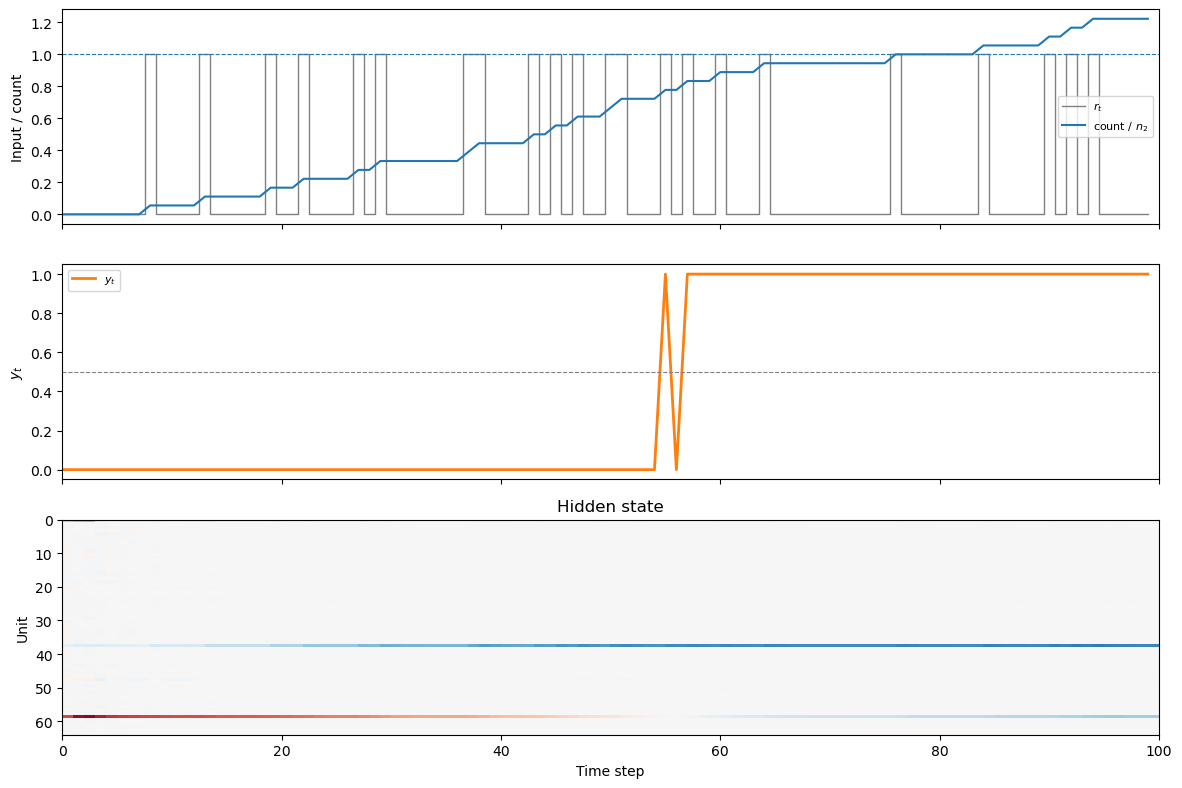

In [220]:
key, ex_key = random.split(key)
ex_inputs        = sample_batch(ex_key, 1, T, P)[0]   # (T, 2)
ex_ys, ex_hs     = forward_single(params, ex_inputs)   # (T,), (T, H)
ex_count         = np.cumsum(np.array(ex_inputs[:, 0]))
ex_ys            = np.array(ex_ys)
ex_hs            = np.array(ex_hs)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].step(range(T), ex_inputs[:, 0], where='mid', c='gray', lw=1.0, label='$r_t$')
axes[0].plot(range(T), ex_count / N_THRESHOLD_2, c='C0', lw=1.5, label='count / $n_2$')
axes[0].axhline(1, ls='--', c='C0', lw=0.8)
axes[0].set_ylabel('Input / count'); axes[0].legend(fontsize=8)

axes[1].plot(range(T), ex_ys, c='C1', lw=2, label='$y_t$')
axes[1].axhline(0.5, ls='--', c='gray', lw=0.8)
axes[1].set_ylabel('$y_t$'); axes[1].set_ylim(-0.05, 1.05); axes[1].legend(fontsize=8)

axes[2].imshow(ex_hs.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1,
               extent=[0, T, HIDDEN_SIZE, 0])
axes[2].set_ylabel('Unit'); axes[2].set_xlabel('Time step')
axes[2].set_title('Hidden state')

fig.tight_layout(); plt.show()


/tmp/ipykernel_23668/4135011948.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


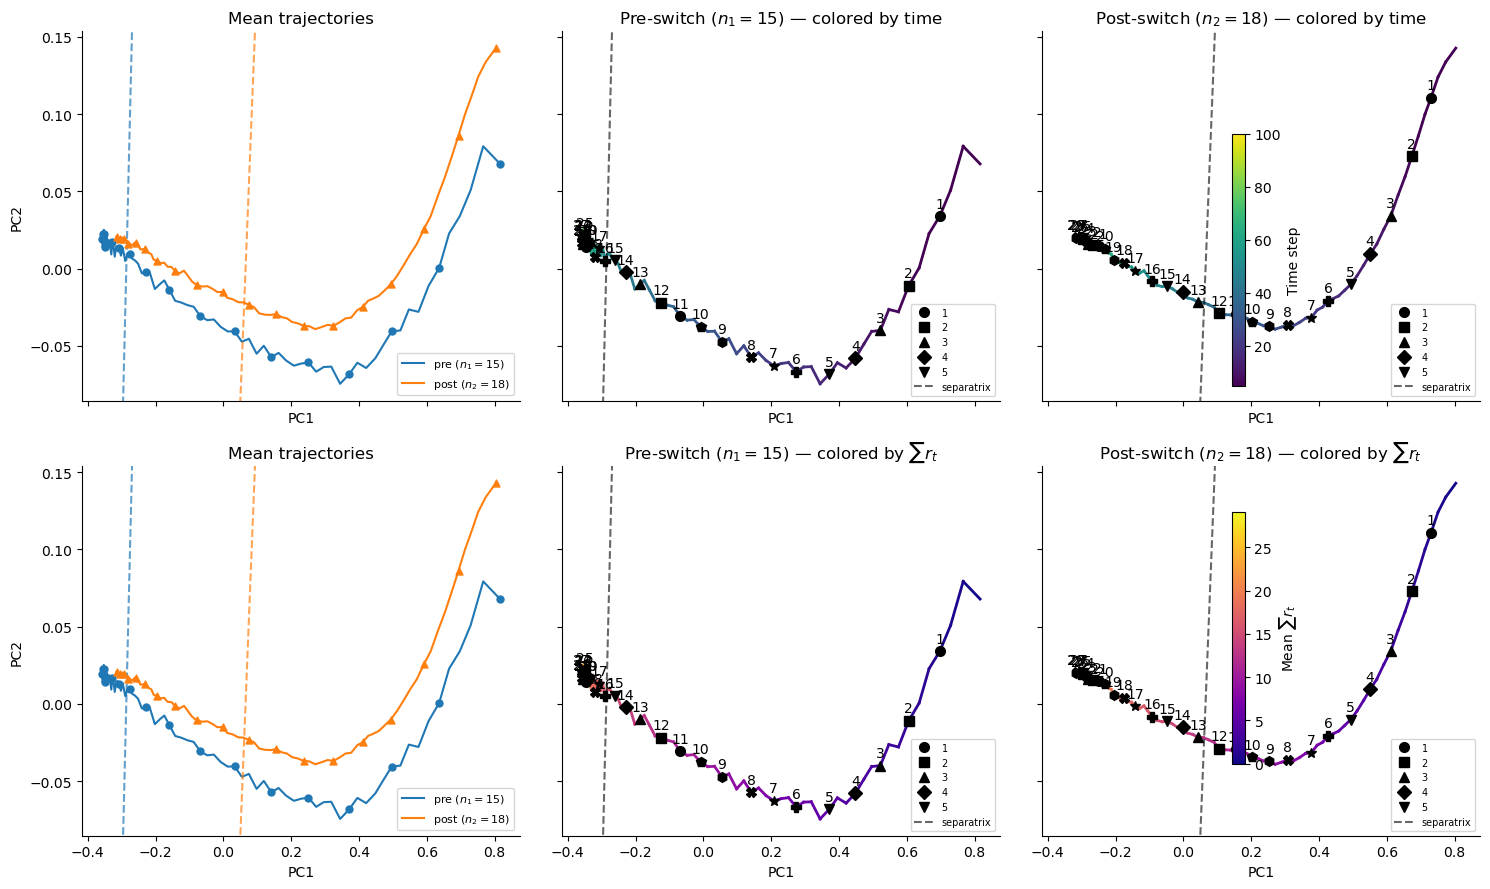

Var explained by PC1-2: 96.0%


In [229]:
key, k1, k2 = random.split(key, 3)
pca_pre_inputs  = sample_batch(k1, 256, T, P)
pca_post_inputs = sample_batch(k2, 256, T, P)

pre_params_jnp = jax.tree_util.tree_map(jnp.array, params_at_switch)
_, pre_hs  = forward_batch(pre_params_jnp, pca_pre_inputs)
_, post_hs = forward_batch(params,          pca_post_inputs)

pre_np  = np.array(pre_hs)
post_np = np.array(post_hs)

# Shared PCA fitted on combined hidden states — only post-delay timesteps
H_combined = np.concatenate([pre_np[:,  DELAY:].reshape(-1, HIDDEN_SIZE),
                              post_np[:, DELAY:].reshape(-1, HIDDEN_SIZE)], axis=0)
pca = PCA(n_components=6)
pca.fit(H_combined)

pre_pc  = pca.transform(pre_np[:,  DELAY:].reshape(-1, HIDDEN_SIZE)).reshape(256, T - DELAY, 6)
post_pc = pca.transform(post_np[:, DELAY:].reshape(-1, HIDDEN_SIZE)).reshape(256, T - DELAY, 6)
pre_mean  = pre_pc.mean(axis=0)   # (T-DELAY, 6)
post_mean = post_pc.mean(axis=0)

pre_cum_r  = np.array(pca_pre_inputs)[:,  DELAY:, 0].cumsum(axis=1).mean(axis=0)
post_cum_r = np.array(pca_post_inputs)[:, DELAY:, 0].cumsum(axis=1).mean(axis=0)
max_count  = max(pre_cum_r.max(), post_cum_r.max())

N_T = T - DELAY

# Marker styles cycling for counts 1, 2, 3, ...
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

def add_count_markers(ax, mean, cum_r):
    n = 1
    while True:
        idx = np.searchsorted(cum_r, n)
        if idx >= len(mean):
            break
        m = MARKERS[(n - 1) % len(MARKERS)]
        ax.plot(mean[idx, 0], mean[idx, 1],
                marker=m, ms=7, c='k', zorder=6, lw=0,
                label=str(n) if n <= 5 else None)
        ax.annotate(str(n), (mean[idx, 0], mean[idx, 1]),
                    fontsize=10, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points')
        n += 1

def draw_trajectory(ax, mean, color_vals, cmap, norm):
    for i in range(len(mean) - 1):
        ax.plot(mean[i:i+2, 0], mean[i:i+2, 1],
                c=cmap(norm(color_vals[i])), lw=2)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True, gridspec_kw={'height_ratios': [1, 1]})

# ── Row 0: colored by time ────────────────────────────────────────────────────
t_norm = plt.Normalize(DELAY, T)
t_cmap = plt.cm.viridis
t_vals = np.arange(N_T)

axes[0, 0].plot(pre_mean[:,  0], pre_mean[:,  1], c='C0', lw=1.5,
                label=f'pre ($n_1={N_THRESHOLD}$)')
axes[0, 0].scatter(pre_mean[::5, 0], pre_mean[::5, 1], c='C0', marker='o', s=25, zorder=3)
axes[0, 0].plot(post_mean[:, 0], post_mean[:, 1], c='C1', lw=1.5,
                label=f'post ($n_2={N_THRESHOLD_2}$)')
axes[0, 0].scatter(post_mean[::5, 0], post_mean[::5, 1], c='C1', marker='^', s=25, zorder=3)
axes[0, 0].set_ylabel('PC2'); axes[0, 0].set_title('Mean trajectories')
axes[0, 0].legend(fontsize=8)

draw_trajectory(axes[0, 1], pre_mean,  t_vals, t_cmap, t_norm)
add_count_markers(axes[0, 1], pre_mean,  pre_cum_r)
axes[0, 1].set_title(f'Pre-switch ($n_1={N_THRESHOLD}$) — colored by time')

draw_trajectory(axes[0, 2], post_mean, t_vals, t_cmap, t_norm)
add_count_markers(axes[0, 2], post_mean, post_cum_r)
axes[0, 2].set_title(f'Post-switch ($n_2={N_THRESHOLD_2}$) — colored by time')

sm_t = plt.cm.ScalarMappable(cmap=t_cmap, norm=t_norm)
fig.colorbar(sm_t, ax=axes[0, 1:], label='Time step', shrink=0.8)

# ── Row 1: colored by cumulative r_t ─────────────────────────────────────────
r_norm = plt.Normalize(0, max_count)
r_cmap = plt.cm.plasma

axes[1, 0].plot(pre_mean[:,  0], pre_mean[:,  1], c='C0', lw=1.5,
                label=f'pre ($n_1={N_THRESHOLD}$)')
axes[1, 0].scatter(pre_mean[::5, 0], pre_mean[::5, 1], c='C0', marker='o', s=25, zorder=3)
axes[1, 0].plot(post_mean[:, 0], post_mean[:, 1], c='C1', lw=1.5,
                label=f'post ($n_2={N_THRESHOLD_2}$)')
axes[1, 0].scatter(post_mean[::5, 0], post_mean[::5, 1], c='C1', marker='^', s=25, zorder=3)
axes[1, 0].set_ylabel('PC2'); axes[1, 0].set_title('Mean trajectories')
axes[1, 0].legend(fontsize=8)

draw_trajectory(axes[1, 1], pre_mean,  pre_cum_r,  r_cmap, r_norm)
add_count_markers(axes[1, 1], pre_mean,  pre_cum_r)
axes[1, 1].set_title(f'Pre-switch ($n_1={N_THRESHOLD}$) — colored by $\\sum r_t$')

draw_trajectory(axes[1, 2], post_mean, post_cum_r, r_cmap, r_norm)
add_count_markers(axes[1, 2], post_mean, post_cum_r)
axes[1, 2].set_title(f'Post-switch ($n_2={N_THRESHOLD_2}$) — colored by $\\sum r_t$')

sm_r = plt.cm.ScalarMappable(cmap=r_cmap, norm=r_norm)
fig.colorbar(sm_r, ax=axes[1, 1:], label='Mean $\\sum r_t$', shrink=0.8)


# ── Separatrix: W_out · h = threshold projected into PC1-PC2 subspace ────────
def sep_line(W_out_np, thresh, pca_obj, x_range):
    # In PC space: a1*PC1 + a2*PC2 = b  →  PC2 = (b - a1*PC1) / a2
    a1 = np.dot(W_out_np, pca_obj.components_[0])
    a2 = np.dot(W_out_np, pca_obj.components_[1])
    b  = thresh - np.dot(W_out_np, pca_obj.mean_)
    if abs(a2) < 1e-10:
        return None, None
    return x_range, (b - a1 * x_range) / a2

pre_W  = np.array(pre_params_jnp['W_out'])
pre_th = float(pre_params_jnp['threshold'])
post_W = np.array(params['W_out'])
post_th = float(params['threshold'])

xlim = axes[0, 0].get_xlim()
ylim = axes[0, 0].get_ylim()
xv   = np.linspace(*xlim, 300)

for row in range(2):
    # col 0: both separatrices in their condition colours
    for W, th, col in [(pre_W, pre_th, 'C0'), (post_W, post_th, 'C1')]:
        xs, ys = sep_line(W, th, pca, xv)
        if xs is not None:
            axes[row, 0].plot(xs, ys, color=col, ls='--', lw=1.5, alpha=0.7)
    # col 1: pre separatrix
    xs, ys = sep_line(pre_W, pre_th, pca, xv)
    if xs is not None:
        axes[row, 1].plot(xs, ys, 'k--', lw=1.5, alpha=0.6, label='separatrix')
        axes[row, 1].legend(fontsize=7, loc='lower right')
    # col 2: post separatrix
    xs, ys = sep_line(post_W, post_th, pca, xv)
    if xs is not None:
        axes[row, 2].plot(xs, ys, 'k--', lw=1.5, alpha=0.6, label='separatrix')
        axes[row, 2].legend(fontsize=7, loc='lower right')

# Restore limits so the separatrix extension doesn't rescale the axes
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

for ax in axes.flat:
    ax.set_xlabel('PC1')
    ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); plt.show()
print(f"Var explained by PC1-2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")


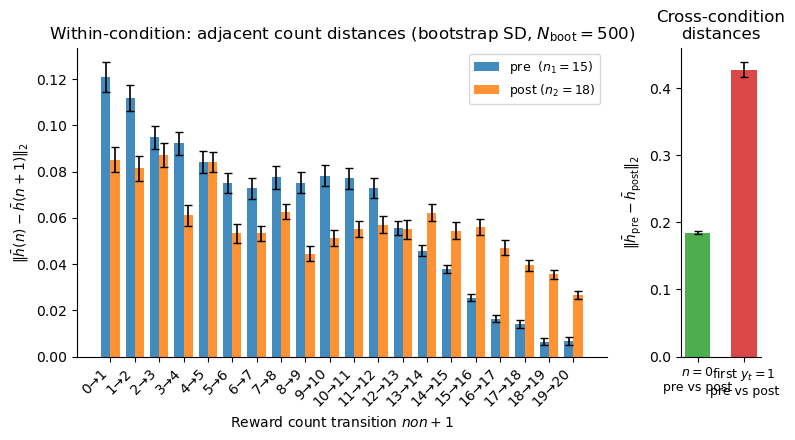

n=0 pre vs post:       0.1845 ± 0.0023
first y=1 pre vs post: 0.4277 ± 0.0107
fired trials  pre=256  post=256


In [238]:
# ── Plot: within-condition adjacent distances + cross-condition anchor distances
# Left panel : ||mean_h(n) - mean_h(n+1)|| for pre and post (grouped bars)
# Right panel: cross-condition distances — n=0 state and first-fire state

N_BOOT   = 500
MIN_SAMP = 15

# ── Within-condition bootstrap ────────────────────────────────────────────────
def bootstrap_distances(hs_np, inputs_np, max_n=20, n_boot=N_BOOT, rng=None):
    rng    = rng or np.random.default_rng(0)
    cum_r  = np.cumsum(inputs_np[:, DELAY:, 0], axis=1).astype(int)
    hs_act = hs_np[:, DELAY:]
    idx = {}
    for n in range(max_n + 1):
        ti, si = np.where(cum_r == n)
        if len(ti) >= MIN_SAMP:
            idx[n] = (ti, si)
    ns_out, mean_out, sem_out = [], [], []
    for n in sorted(idx):
        if (n + 1) not in idx:
            continue
        ti_n,  si_n  = idx[n]
        ti_n1, si_n1 = idx[n + 1]
        boot = np.empty(n_boot)
        for b in range(n_boot):
            s0 = rng.integers(0, len(ti_n),  size=len(ti_n))
            s1 = rng.integers(0, len(ti_n1), size=len(ti_n1))
            h0 = hs_act[ti_n[s0],   si_n[s0]  ].mean(axis=0)
            h1 = hs_act[ti_n1[s1],  si_n1[s1] ].mean(axis=0)
            boot[b] = np.linalg.norm(h0 - h1)
        ns_out.append(n); mean_out.append(boot.mean()); sem_out.append(boot.std())
    return np.array(ns_out), np.array(mean_out), np.array(sem_out)

# ── Cross-condition bootstrap ─────────────────────────────────────────────────
def bootstrap_cross(pool1, pool2, n_boot=N_BOOT, rng=None):
    rng = rng or np.random.default_rng(0)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        s1 = rng.integers(0, len(pool1), size=len(pool1))
        s2 = rng.integers(0, len(pool2), size=len(pool2))
        boot[b] = np.linalg.norm(pool1[s1].mean(axis=0) - pool2[s2].mean(axis=0))
    return boot.mean(), boot.std()

rng = np.random.default_rng(42)

ns_pre,  ds_pre,  se_pre  = bootstrap_distances(pre_np,  np.array(pca_pre_inputs),  rng=rng)
ns_post, ds_post, se_post = bootstrap_distances(post_np, np.array(pca_post_inputs), rng=rng)

# Cross 1: n=0 state (all timesteps where cumsum r_t == 0, post-delay)
cum_r_pre  = np.cumsum(np.array(pca_pre_inputs)[:,  DELAY:, 0], axis=1).astype(int)
cum_r_post = np.cumsum(np.array(pca_post_inputs)[:, DELAY:, 0], axis=1).astype(int)
hs_pre_act  = pre_np[:,  DELAY:]
hs_post_act = post_np[:, DELAY:]

ti0p, si0p = np.where(cum_r_pre  == 0)
ti0q, si0q = np.where(cum_r_post == 0)
d0_mean, d0_sem = bootstrap_cross(hs_pre_act[ti0p, si0p],
                                  hs_post_act[ti0q, si0q], rng=rng)

# Cross 2: hidden state at first timestep where y_t = 1
ys_pre,  _ = forward_batch(pre_params_jnp, pca_pre_inputs)
ys_post, _ = forward_batch(params,          pca_post_inputs)
ys_pre_np  = np.array(ys_pre)    # (B, T)
ys_post_np = np.array(ys_post)

def first_fire_pool(ys_np, hs_np):
    pool = []
    for i in range(ys_np.shape[0]):
        fired = ys_np[i] > 0.5
        if fired.any():
            pool.append(hs_np[i, int(np.argmax(fired))])
    return np.array(pool)

pool_pre_fire  = first_fire_pool(ys_pre_np,  pre_np)
pool_post_fire = first_fire_pool(ys_post_np, post_np)
dy_mean, dy_sem = bootstrap_cross(pool_pre_fire, pool_post_fire, rng=rng)

# ── Plot ───────────────────────────────────────────────────────────────────────
ns_all    = np.union1d(ns_pre, ns_post)
pre_vals  = np.array([ds_pre [ns_pre  == n][0] if n in ns_pre  else np.nan for n in ns_all])
post_vals = np.array([ds_post[ns_post == n][0] if n in ns_post else np.nan for n in ns_all])
pre_errs  = np.array([se_pre [ns_pre  == n][0] if n in ns_pre  else np.nan for n in ns_all])
post_errs = np.array([se_post[ns_post == n][0] if n in ns_post else np.nan for n in ns_all])

width = 0.38
x     = np.arange(len(ns_all))
ecap  = dict(ecolor='k', elinewidth=1.2, capsize=3, capthick=1)

n_main = len(ns_all)
fig, (ax_main, ax_cross) = plt.subplots(
    1, 2, figsize=(8, 4.5),
    gridspec_kw={'width_ratios': [n_main, 3]})

ax_main.bar(x - width/2, pre_vals,  width, color='C0', alpha=0.85,
            yerr=pre_errs,  error_kw=ecap, label=f'pre  ($n_1={N_THRESHOLD}$)')
ax_main.bar(x + width/2, post_vals, width, color='C1', alpha=0.85,
            yerr=post_errs, error_kw=ecap, label=f'post ($n_2={N_THRESHOLD_2}$)')
ax_main.set_xticks(x)
ax_main.set_xticklabels([f'{int(n)}\u2192{int(n)+1}' for n in ns_all], rotation=45, ha='right')
ax_main.set_xlabel('Reward count transition $n \to n+1$')
ax_main.set_ylabel(r'$\|\bar{h}(n) - \bar{h}(n+1)\|_2$')
ax_main.set_title(f'Within-condition: adjacent count distances '
                  f'(bootstrap SD, $N_{{\mathrm{{boot}}}}={N_BOOT}$)')
ax_main.legend(fontsize=9)
ax_main.spines[['top', 'right']].set_visible(False)

ax_cross.bar([0, 1], [d0_mean, dy_mean], 0.55,
             color=['C2', 'C3'], alpha=0.85,
             yerr=[d0_sem, dy_sem], error_kw=ecap)
ax_cross.set_xticks([0, 1])
ax_cross.set_xticklabels(['$n=0$\npre vs post', 'first $y_t=1$\npre vs post'], fontsize=9)
ax_cross.set_ylabel(r'$\|\bar{h}_{\mathrm{pre}} - \bar{h}_{\mathrm{post}}\|_2$')
ax_cross.set_title('Cross-condition\ndistances')
ax_cross.spines[['top', 'right']].set_visible(False)

fig.tight_layout(); plt.show()
print(f'n=0 pre vs post:       {d0_mean:.4f} \u00b1 {d0_sem:.4f}')
print(f'first y=1 pre vs post: {dy_mean:.4f} \u00b1 {dy_sem:.4f}')
print(f'fired trials  pre={len(pool_pre_fire)}  post={len(pool_post_fire)}')


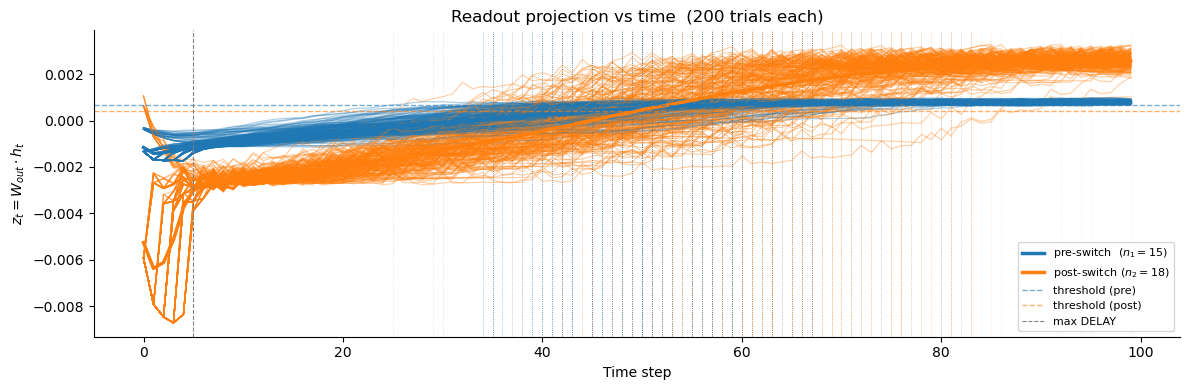

In [222]:
# ── Plot: readout projection vs time — pre-switch vs post-training ────────────
# Each trial projected onto its own network's W_out: z_t = W_out · h_t

N_TRIALS = 200
key, k1, k2 = random.split(key, 3)
pre_inputs  = sample_batch(k1, N_TRIALS, T, P)
post_inputs = sample_batch(k2, N_TRIALS, T, P)

pre_params = jax.tree_util.tree_map(jnp.array, params_at_switch)
_, pre_hs  = forward_batch(pre_params, pre_inputs)    # (N, T, H)
_, post_hs = forward_batch(params,     post_inputs)

# Readout projections using each network's own W_out
z_pre  = np.array(pre_hs)  @ np.array(params_at_switch['W_out'])   # (N, T)
z_post = np.array(post_hs) @ np.array(params['W_out'])

pre_counts  = np.cumsum(np.array(pre_inputs[:,  :, 0]), axis=1)
post_counts = np.cumsum(np.array(post_inputs[:, :, 0]), axis=1)

def crossing_idx(counts, n_thresh):
    crossed = counts >= n_thresh
    idx = np.argmax(crossed, axis=1)
    idx[~crossed.any(axis=1)] = T - 1
    return idx

pre_cross  = crossing_idx(pre_counts,  N_THRESHOLD)
post_cross = crossing_idx(post_counts, N_THRESHOLD_2)

ts = np.arange(T)
fig, ax = plt.subplots(figsize=(12, 4))

for i in range(N_TRIALS):
    ax.plot(ts, z_pre[i],  c='C0', lw=0.9, alpha=0.35)
    ax.plot(ts, z_post[i], c='C1', lw=0.9, alpha=0.35)
    ax.axvline(pre_cross[i],  c='C0', lw=0.6, alpha=0.2, ls=':')
    ax.axvline(post_cross[i], c='C1', lw=0.6, alpha=0.2, ls=':')

ax.plot(ts, z_pre.mean(0),  c='C0', lw=2.5, label=f'pre-switch  ($n_1={N_THRESHOLD}$)')
ax.plot(ts, z_post.mean(0), c='C1', lw=2.5, label=f'post-switch ($n_2={N_THRESHOLD_2}$)')
ax.axhline(float(params_at_switch['threshold']), c='C0', ls='--', lw=1.0, alpha=0.6, label='threshold (pre)')
ax.axhline(float(params['threshold']),           c='C1', ls='--', lw=1.0, alpha=0.6, label='threshold (post)')
ax.axvline(DELAY, c='gray', ls='--', lw=0.8, label='max DELAY')
ax.set_xlabel('Time step')
ax.set_ylabel('$z_t = W_{out} \\cdot h_t$')
ax.set_title(f'Readout projection vs time  ({N_TRIALS} trials each)')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
fig.tight_layout(); plt.show()


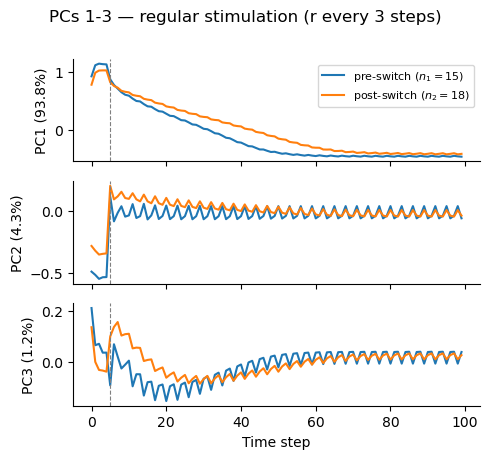

Variance explained: [93.780045   4.2970195  1.2260495]


In [223]:
# ── Plot: PC 1-3 vs time under regular stimulation ───────────────────────────
# r_t delivered deterministically every round(1/p) steps after a fixed delay.

reg_step = int(round(1.0 / P))
t_idx    = np.arange(T)

active   = t_idx >= DELAY
offsets  = (t_idx - DELAY) % reg_step == 0
r_reg    = (active & offsets).astype(np.float32)
g_reg    = (~active).astype(np.float32)
reg_input = jnp.array(np.stack([r_reg, g_reg], axis=-1))[None]   # (1, T, 2)

pre_params_jnp = jax.tree_util.tree_map(jnp.array, params_at_switch)
_, pre_reg_hs  = forward_batch(pre_params_jnp, reg_input)
_, post_reg_hs = forward_batch(params,          reg_input)

pre_reg_np  = np.array(pre_reg_hs[0])    # (T, H)
post_reg_np = np.array(post_reg_hs[0])

pca_reg = PCA(n_components=3)
pca_reg.fit(post_reg_np)
pre_pc  = pca_reg.transform(pre_reg_np)   # (T, 3)
post_pc = pca_reg.transform(post_reg_np)

fig, axes = plt.subplots(3, 1, figsize=(5, 4.5), sharex=True)
for pc_idx, ax in enumerate(axes):
    ax.plot(t_idx, pre_pc[:,  pc_idx], c='C0', lw=1.5, label=f'pre-switch ($n_1={N_THRESHOLD}$)')
    ax.plot(t_idx, post_pc[:, pc_idx], c='C1', lw=1.5, label=f'post-switch ($n_2={N_THRESHOLD_2}$)')
    ax.axvline(DELAY, c='gray', ls='--', lw=0.8)
    var_pct = pca_reg.explained_variance_ratio_[pc_idx] * 100
    ax.set_ylabel(f'PC{pc_idx+1} ({var_pct:.1f}%)')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(fontsize=8)
axes[-1].set_xlabel('Time step')
fig.suptitle(f'PCs 1-3 — regular stimulation (r every {reg_step} steps)', y=1.01)
fig.tight_layout()
plt.show()
print(f'Variance explained: {pca_reg.explained_variance_ratio_[:3] * 100}')

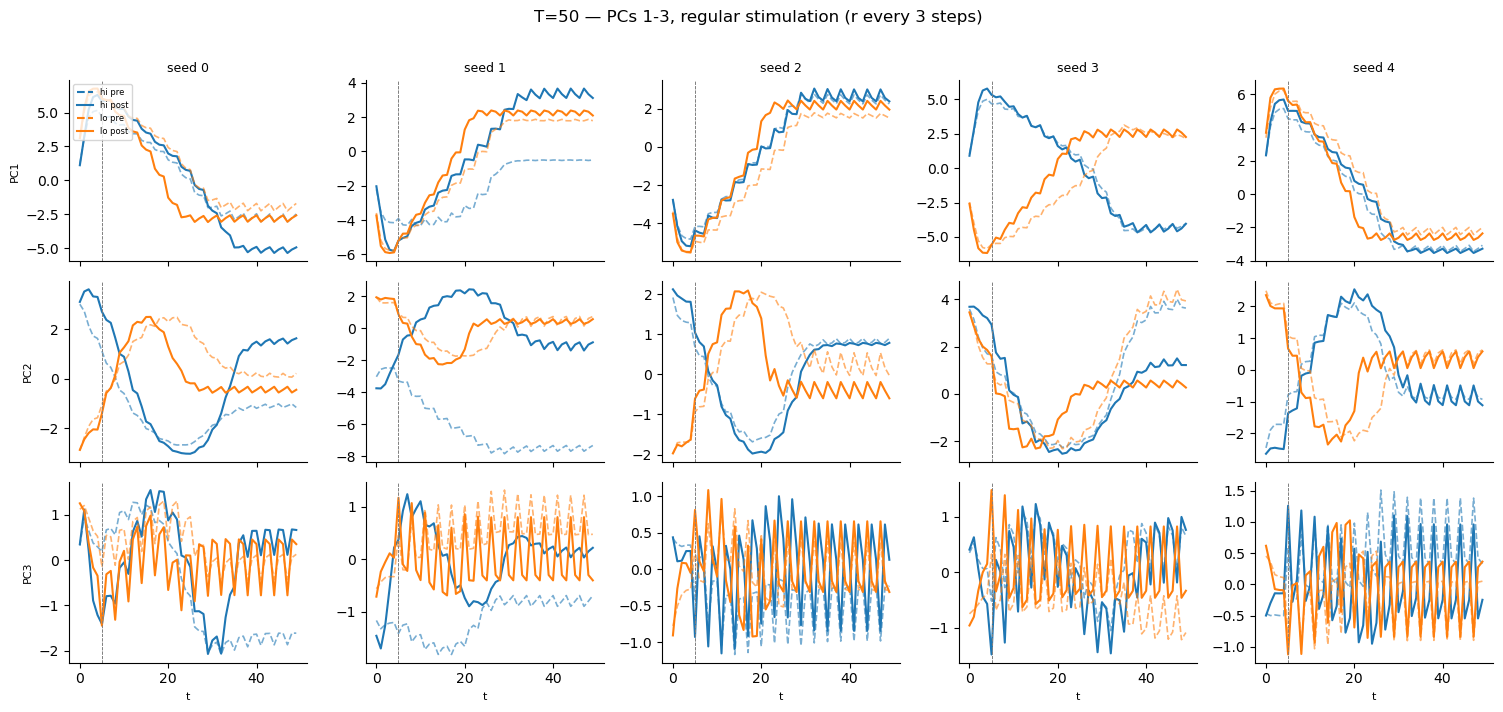

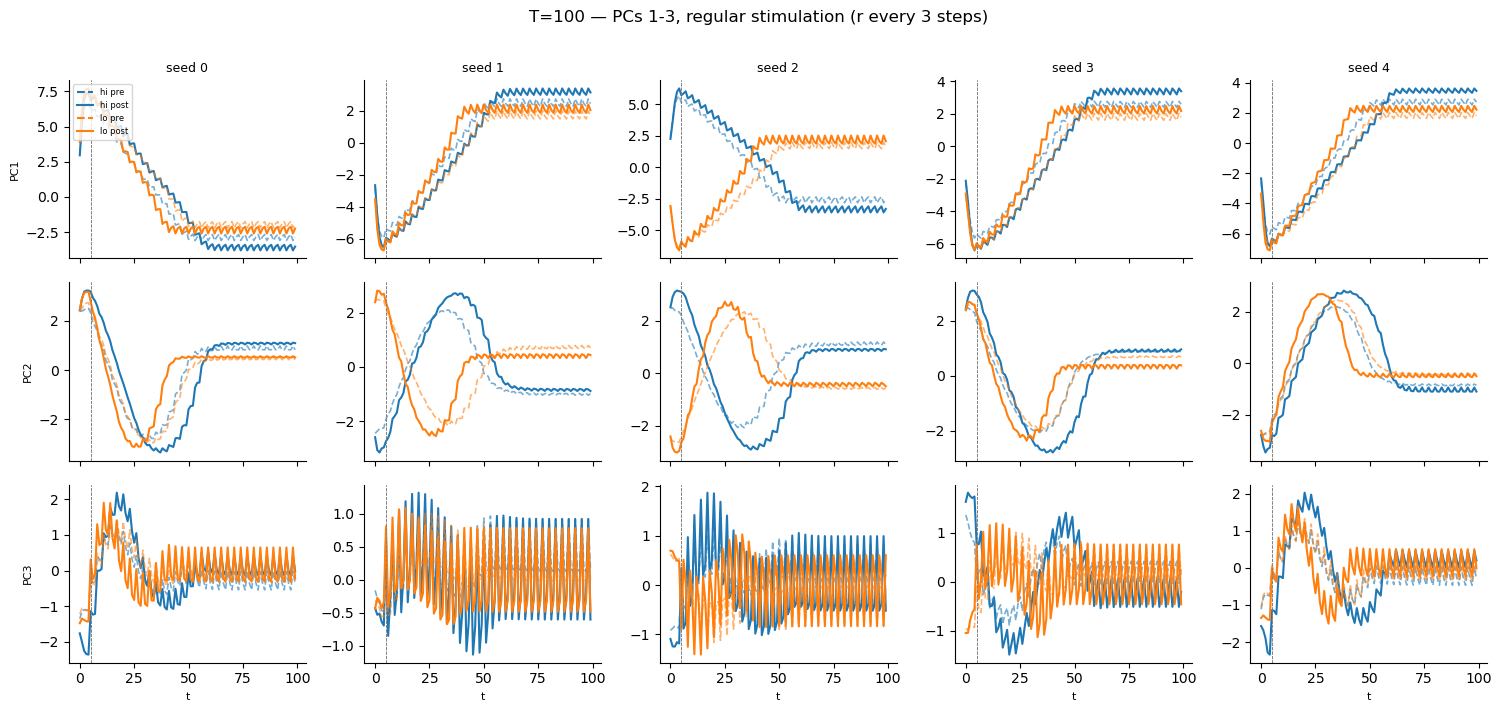

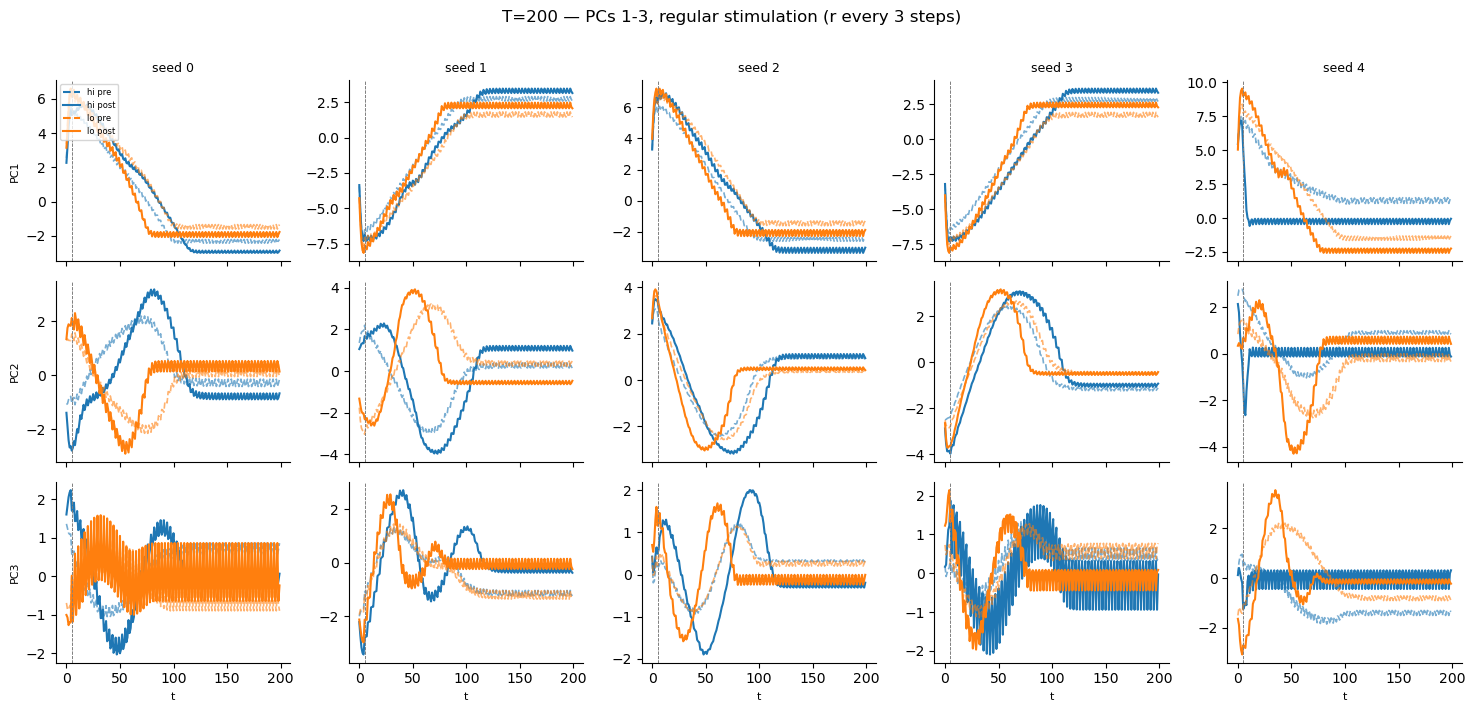

In [239]:
# ── Plot: PC 1-3 vs time (regular stimulation) — sweep networks ──────────────
# Same single-trial regular stimulus; one figure per T value.
# 3 rows (PCs) × 5 cols (seeds); two conditions overlaid per subplot.

cond_list   = list(CONDITIONS.keys())
cond_colors = ['C0', 'C1']

for T_val in T_VALUES:
    reg_step_v = int(round(1.0 / P))
    t_idx_v    = np.arange(T_val)

    active_v  = t_idx_v >= DELAY
    offsets_v = (t_idx_v - DELAY) % reg_step_v == 0
    r_reg_v   = (active_v & offsets_v).astype(np.float32)
    g_reg_v   = (~active_v).astype(np.float32)
    reg_input_v = jnp.array(np.stack([r_reg_v, g_reg_v], axis=-1))[None]   # (1, T, 2)

    fig, axes = plt.subplots(3, N_SEEDS_SWEEP,
                             figsize=(3.0 * N_SEEDS_SWEEP, 7),
                             sharex=True)

    for col, seed in enumerate(range(N_SEEDS_SWEEP)):
        for ci, (cond_name, cc) in enumerate(zip(cond_list, cond_colors)):
            r = next(r for r in sweep_results
                     if r['T'] == T_val and r['condition'] == cond_name and r['seed'] == seed)

            p_pre  = jax.tree_util.tree_map(jnp.array, r['params_at_switch'])
            p_post = jax.tree_util.tree_map(jnp.array, r['params_final'])
            _, pre_hs  = forward_batch(p_pre,  reg_input_v)
            _, post_hs = forward_batch(p_post, reg_input_v)
            pre_np  = np.array(pre_hs[0])    # (T, H)
            post_np = np.array(post_hs[0])

            # PCA fit on this network's post-switch response
            pca_v = PCA(n_components=3)
            pca_v.fit(post_np)
            pre_pc_v  = pca_v.transform(pre_np)
            post_pc_v = pca_v.transform(post_np)

            for pc_idx in range(3):
                ax = axes[pc_idx, col]
                ax.plot(t_idx_v, pre_pc_v[:,  pc_idx], c=cc, lw=1.2, ls='--', alpha=0.6)
                ax.plot(t_idx_v, post_pc_v[:, pc_idx], c=cc, lw=1.5)
                ax.axvline(DELAY, c='gray', ls='--', lw=0.6)
                ax.spines[['top', 'right']].set_visible(False)
                if col == 0:
                    ax.set_ylabel(f'PC{pc_idx+1}', fontsize=8)
                if pc_idx == 2:
                    ax.set_xlabel('t', fontsize=8)
                if pc_idx == 0:
                    ax.set_title(f'seed {seed}', fontsize=9)

    from matplotlib.lines import Line2D
    legend_handles = []
    for cond_name, cc in zip(cond_list, cond_colors):
        short = 'hi' if 'high' in cond_name else 'lo'
        legend_handles += [
            Line2D([0],[0], c=cc, lw=1.5, ls='--', label=f'{short} pre'),
            Line2D([0],[0], c=cc, lw=1.5,           label=f'{short} post'),
        ]
    axes[0, 0].legend(handles=legend_handles, fontsize=6, loc='upper left')
    fig.suptitle(f'T={T_val} — PCs 1-3, regular stimulation (r every {reg_step_v} steps)', y=1.01)
    fig.tight_layout()
    plt.show()


In [ ]:
# ── Sweep: T × (conditions × seeds in parallel) ──────────────────────────────
T_VALUES           = [50, 100, 200]
N_SEEDS_SWEEP      = 5
CONDITIONS         = {'high (0.6pT)': 0.6, 'low (0.4pT)': 0.4}
RECORD_EVERY_SWEEP = 200
BATCH_SIZE_SWEEP   = BATCH_SIZE // 10   # smaller per-network batch; compensated by parallelism

sweep_results = []
sw_switch     = N_STEPS // 2
sweep_steps   = list(range(0, N_STEPS, RECORD_EVERY_SWEEP))

# All (condition, seed) pairs — run simultaneously across the GPU
configs    = [(cond, seed) for cond in CONDITIONS for seed in range(N_SEEDS_SWEEP)]
N_PARALLEL = len(configs)   # 2 × 5 = 10

for T_val in T_VALUES:
    n1  = int(round(P * T_val * 0.5))
    n1s = jnp.full((N_PARALLEL,), float(n1))
    n2s = jnp.array([float(int(round(P * T_val * CONDITIONS[cond])))
                     for cond, _ in configs])
    opt_s = optax.adam(LR)

    # Initialise N_PARALLEL independent networks
    base_keys  = jnp.stack([random.PRNGKey(1000 + seed) for _, seed in configs])
    splits     = jax.vmap(random.split)(base_keys)   # (N, 2)
    run_keys   = splits[:, 0]
    init_keys  = splits[:, 1]
    all_params     = jax.vmap(init_params)(init_keys)
    all_opt_states = jax.vmap(opt_s.init)(all_params)

    @jax.jit
    def batched_step(all_params, all_opt_states, all_keys, all_n_thresh,
                     _T=T_val, _opt=opt_s):
        def single(params, opt_state, key, n_threshold):
            key, subkey, noise_key = random.split(key, 3)
            inputs = sample_batch(subkey, BATCH_SIZE_SWEEP, _T, P)
            def loss_with_acc(p):
                noise   = random.normal(noise_key, (BATCH_SIZE_SWEEP, _T, HIDDEN_SIZE)) * UNIT_NOISE_STD
                ys, hs  = forward_batch_noisy(p, inputs, noise)
                ys_star = targets(inputs, n_threshold)
                mse     = jnp.mean((ys - ys_star) ** 2)
                l2      = L2_W * sum(jnp.mean(v**2) for v in jax.tree_util.tree_leaves(p))
                l2_act  = L2_H * jnp.mean(hs ** 2)
                acc     = jnp.mean((ys > 0.5) == (ys_star > 0.5))
                return mse + l2 + l2_act, acc
            (loss, acc), grads = jax.value_and_grad(loss_with_acc, has_aux=True)(params)
            updates, new_opt_state = _opt.update(grads, opt_state)
            return optax.apply_updates(params, updates), new_opt_state, key, loss, acc
        return jax.vmap(single)(all_params, all_opt_states, all_keys, all_n_thresh)

    all_params_at_switch = None
    loss_hists = [[] for _ in configs]
    acc_hists  = [[] for _ in configs]

    for step_i in range(N_STEPS):
        n_thresh = n1s if step_i < sw_switch else n2s
        all_params, all_opt_states, run_keys, losses, accs = batched_step(
            all_params, all_opt_states, run_keys, n_thresh)
        if step_i == sw_switch - 1:
            all_params_at_switch = jax.tree_util.tree_map(lambda x: np.array(x), all_params)
        if step_i % RECORD_EVERY_SWEEP == 0:
            for i in range(N_PARALLEL):
                loss_hists[i].append(float(losses[i]))
                acc_hists[i].append(float(accs[i]))

    # Unpack batch dimension into per-run result dicts
    params_final_np = jax.tree_util.tree_map(lambda x: np.array(x), all_params)
    for i, (cond_name, seed) in enumerate(configs):
        sweep_results.append(dict(
            T=T_val, condition=cond_name, seed=seed,
            loss_hist=loss_hists[i], acc_hist=acc_hists[i],
            params_final=jax.tree_util.tree_map(lambda x: x[i], params_final_np),
            params_at_switch=jax.tree_util.tree_map(lambda x: x[i], all_params_at_switch),
        ))
    final_accs = [f'{acc_hists[i][-1]:.2f}' for i in range(N_PARALLEL)]
    print(f'T={T_val:4d}  final acc: {final_accs}')

print(f'\nTotal runs: {len(sweep_results)}')


T=  50  final acc: ['1.00', '1.00', '0.99', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']


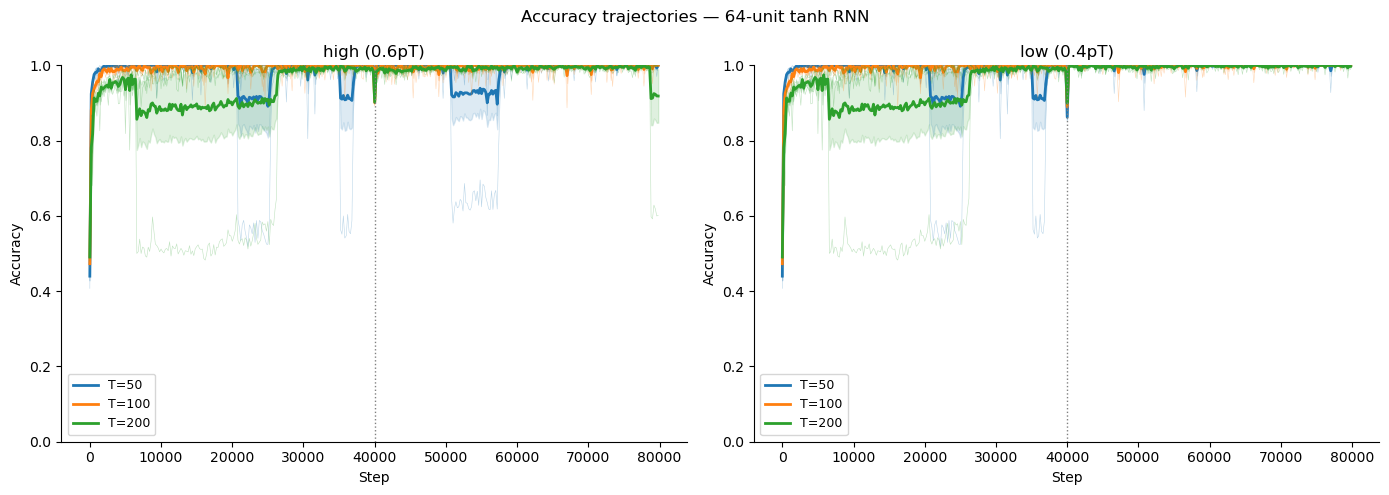

In [104]:
T_colors = {t: f'C{i}' for i, t in enumerate(T_VALUES)}
xs_sw = np.array(sweep_steps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cond_name in zip(axes, CONDITIONS):
    for T_val in T_VALUES:
        rows  = [r for r in sweep_results if r['T'] == T_val and r['condition'] == cond_name]
        hists = np.array([r['acc_hist'] for r in rows])
        mean  = hists.mean(axis=0)
        sem   = hists.std(axis=0) / np.sqrt(len(rows))
        c     = T_colors[T_val]
        for h in hists:
            ax.plot(xs_sw, h, color=c, lw=0.4, alpha=0.3)
        ax.plot(xs_sw, mean, color=c, lw=2, label=f'T={T_val}')
        ax.fill_between(xs_sw, mean - sem, mean + sem, color=c, alpha=0.15)
    ax.axvline(sw_switch, c='gray', ls=':', lw=1)
    ax.set_xlabel('Step'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1); ax.set_title(cond_name)
    ax.legend(fontsize=9); ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('Accuracy trajectories — 64-unit tanh RNN')
fig.tight_layout(); plt.show()


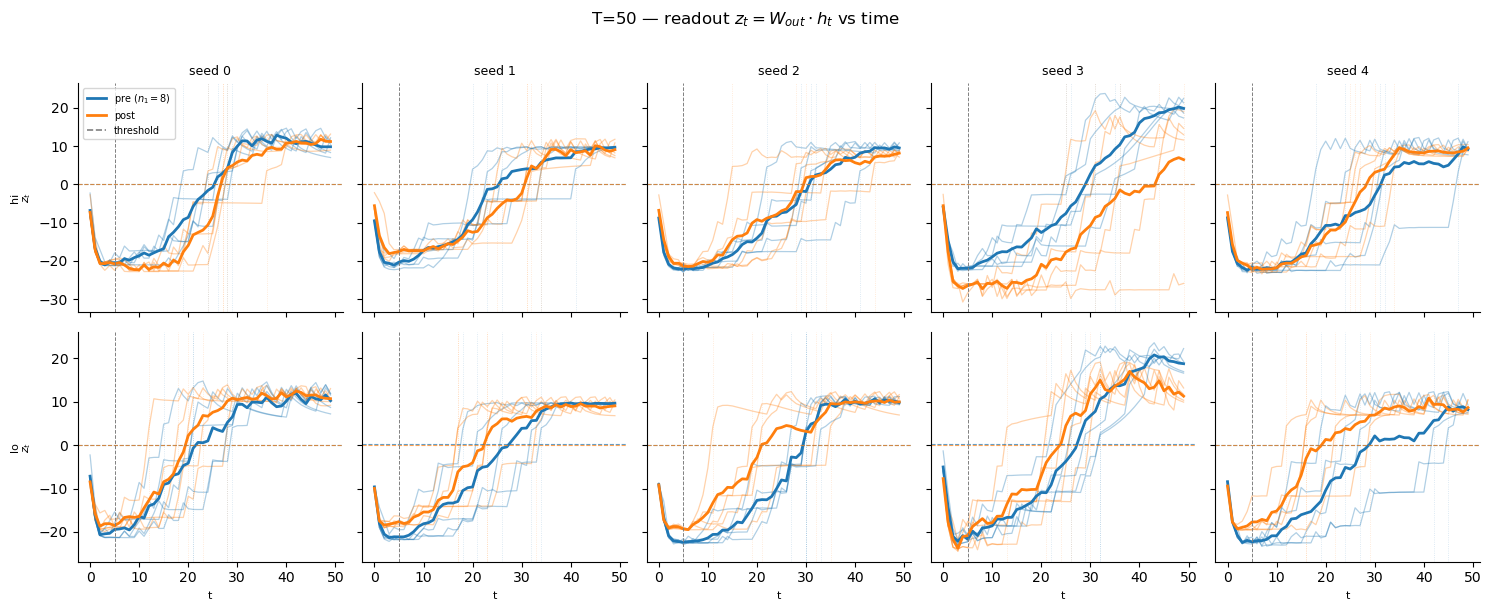

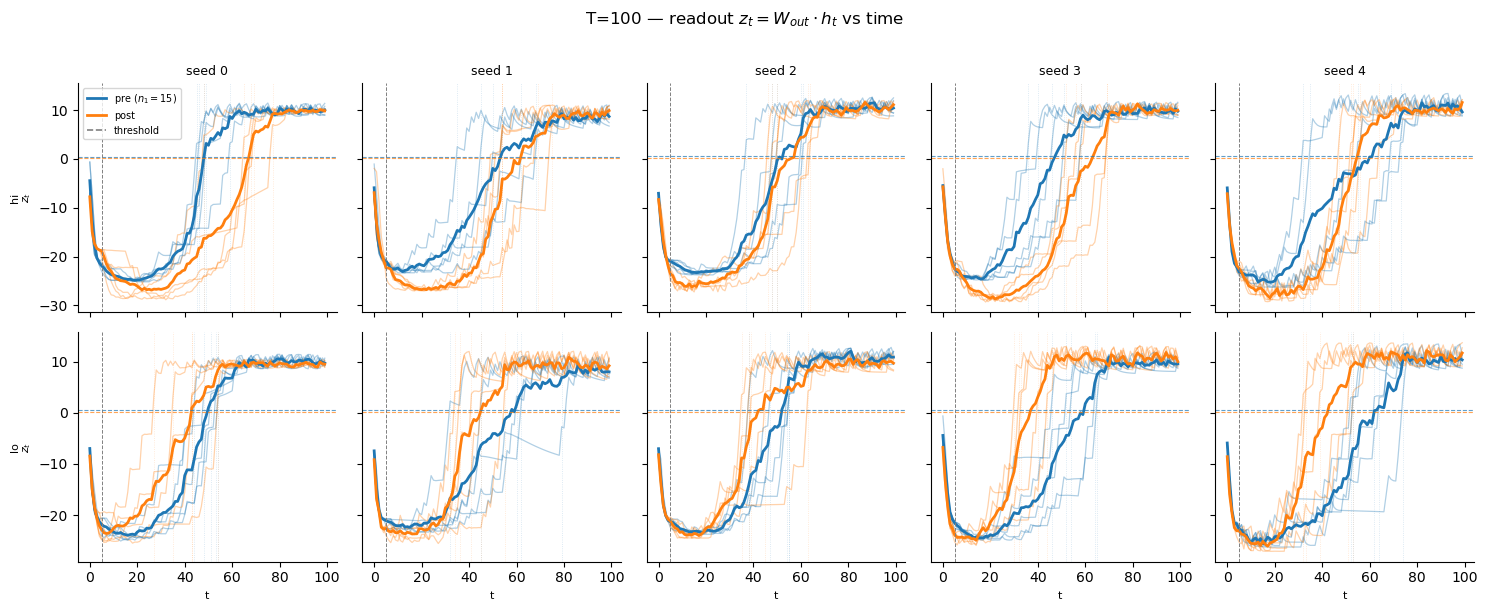

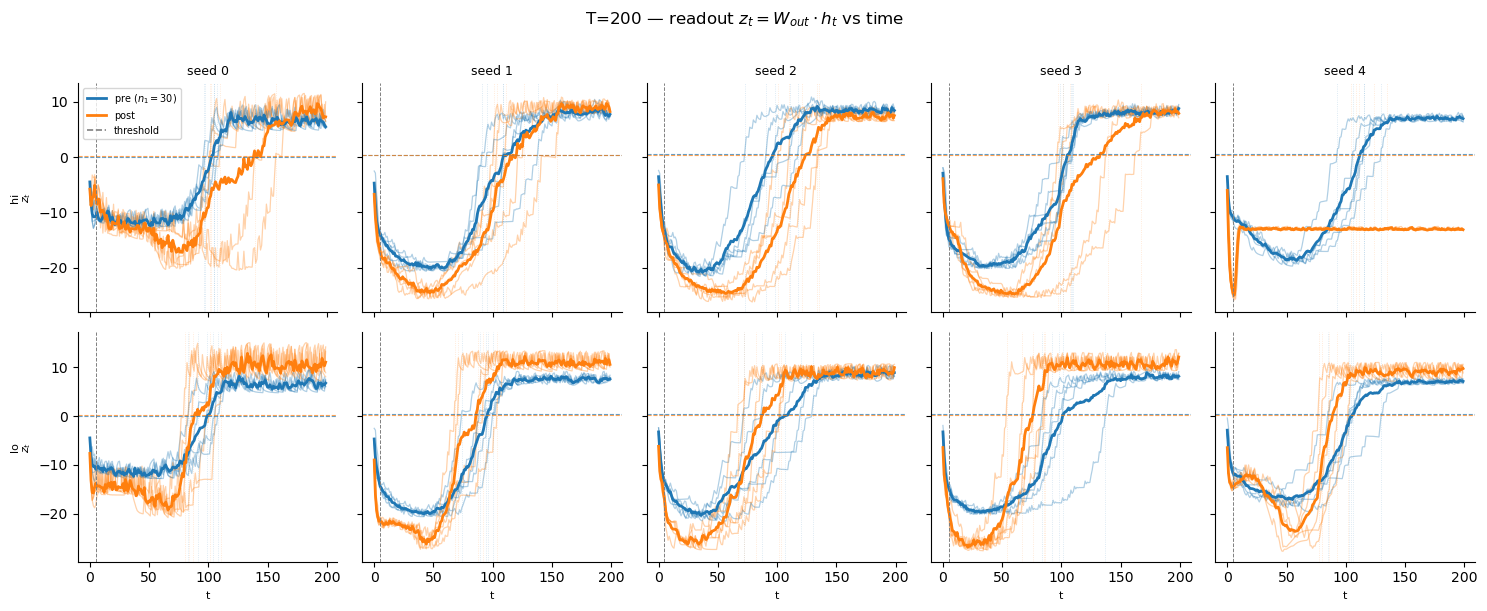

In [111]:
# ── Plot: readout projection vs time — 5 cols (seeds) × 2 rows (conditions) ──
N_TRIALS_TRAJ = 5
eval_key_base = random.PRNGKey(9999)
cond_list     = list(CONDITIONS.keys())

def crossing_idx(counts, n_thresh, T_val):
    crossed = counts >= n_thresh
    idx = np.argmax(crossed, axis=1)
    idx[~crossed.any(axis=1)] = T_val - 1
    return idx

for T_val in T_VALUES:
    n1     = int(round(P * T_val * 0.5))
    rows_T = [r for r in sweep_results if r['T'] == T_val]

    # Generate eval trajectories and readout projections for every network
    net_data = {}
    for r in rows_T:
        n2  = int(round(P * T_val * CONDITIONS[r['condition']]))
        ek  = random.fold_in(eval_key_base,
                             hash((T_val, r['condition'], r['seed'])) & 0xFFFFFFFF)
        ek, k1, k2 = random.split(ek, 3)
        pre_in  = sample_batch(k1, N_TRIALS_TRAJ, T_val, P)
        post_in = sample_batch(k2, N_TRIALS_TRAJ, T_val, P)

        p_pre  = jax.tree_util.tree_map(jnp.array, r['params_at_switch'])
        p_post = jax.tree_util.tree_map(jnp.array, r['params_final'])
        _, pre_hs  = forward_batch(p_pre,  pre_in)
        _, post_hs = forward_batch(p_post, post_in)

        # Project onto each network's own W_out
        z_pre  = np.array(pre_hs)  @ np.array(r['params_at_switch']['W_out'])  # (N, T)
        z_post = np.array(post_hs) @ np.array(r['params_final']['W_out'])

        pre_counts  = np.cumsum(np.array(pre_in[:,  :, 0]), axis=1)
        post_counts = np.cumsum(np.array(post_in[:, :, 0]), axis=1)
        net_data[(r['condition'], r['seed'])] = dict(
            n2=n2,
            z_pre=z_pre, z_post=z_post,
            thr_pre=float(r['params_at_switch']['threshold']),
            thr_post=float(r['params_final']['threshold']),
            pre_cross=crossing_idx(pre_counts, n1, T_val),
            post_cross=crossing_idx(post_counts, n2, T_val),
        )

    ts      = np.arange(T_val)
    n_seeds = N_SEEDS_SWEEP
    n_rows  = len(cond_list)   # 2
    fig, axes = plt.subplots(n_rows, n_seeds,
                             figsize=(3.0 * n_seeds, 3.0 * n_rows),
                             sharex=True, sharey='row')

    for row, cond_name in enumerate(cond_list):
        n2 = int(round(P * T_val * CONDITIONS[cond_name]))
        for col, seed in enumerate(range(n_seeds)):
            ax = axes[row, col]
            d  = net_data[(cond_name, seed)]
            for i in range(N_TRIALS_TRAJ):
                ax.plot(ts, d['z_pre'][i],  c='C0', lw=0.9, alpha=0.35)
                ax.plot(ts, d['z_post'][i], c='C1', lw=0.9, alpha=0.35)
                ax.axvline(d['pre_cross'][i],  c='C0', lw=0.6, alpha=0.2, ls=':')
                ax.axvline(d['post_cross'][i], c='C1', lw=0.6, alpha=0.2, ls=':')
            ax.plot(ts, d['z_pre'].mean(0),  c='C0', lw=2.0)
            ax.plot(ts, d['z_post'].mean(0), c='C1', lw=2.0)
            ax.axhline(d['thr_pre'],  c='C0', ls='--', lw=0.8, alpha=0.7)
            ax.axhline(d['thr_post'], c='C1', ls='--', lw=0.8, alpha=0.7)
            ax.axvline(DELAY, c='gray', ls='--', lw=0.7)
            ax.spines[['top', 'right']].set_visible(False)
            if col == 0:
                short = 'hi' if 'high' in cond_name else 'lo'
                ax.set_ylabel(f'{short}\n$z_t$', fontsize=8)
            if row == 0:
                ax.set_title(f'seed {seed}', fontsize=9)
            if row == n_rows - 1:
                ax.set_xlabel('t', fontsize=8)

    from matplotlib.lines import Line2D
    axes[0, 0].legend(handles=[
        Line2D([0],[0], color='C0', lw=2,  label=f'pre ($n_1={n1}$)'),
        Line2D([0],[0], color='C1', lw=2,  label='post'),
        Line2D([0],[0], color='gray', lw=1.2, ls='--', label='threshold'),
    ], fontsize=7, loc='upper left')

    fig.suptitle(f'T={T_val} — readout $z_t = W_{{out}} \\cdot h_t$ vs time', y=1.01)
    fig.tight_layout()
    plt.show()
